# Customer Segmentation & Retention Analysis

## Project Overview
This project leverages advanced data analytics and machine learning to segment a customer base into distinct groups. By understanding the unique behaviors, spending habits, and demographic profiles of these segments, the business can optimize marketing spend, improve customer retention, and personalize promotional offers.

## Key Objectives
*   **Identify Customer Personas**: Group customers based on shared characteristics.
*   **Analyze Spending Behavior**: Understand who spends the most and on what products.
*   **Optimize Campaign Strategy**: Determine which segments are most responsive to promotions.

## The Data-Driven Personas
Through clustering analysis, we identified three primary customer segments:

1.  **Wealthy Non-Parents** (Cluster 1)
    *   **Profile**: High income, high spending, no children in the household.
    *   **Behavior**: Most frequent purchasers of premium products like wine and meat.
    *   **Opportunity**: High-value loyalty programs and luxury product launches.

2.  **Affluent Parents** (Cluster 2)
    *   **Profile**: High income, high spending, but with children.
    *   **Behavior**: Significant spending power but likely driven by family needs.
    *   **Opportunity**: Family-oriented premium bundles and convenience-based services.

3.  **Budget-Conscious Parents** (Cluster 0)
    *   **Profile**: Lower income and lower spending, primarily parents.
    *   **Behavior**: Responsive to deals and price-sensitive.
    *   **Opportunity**: Targeted discounts, 'deal' notifications, and value-based marketing.

## Methodology (Simplified)
*   **Data Cleaning**: Removed outliers and handled missing information to ensure accuracy.
*   **Feature Engineering**: Created new metrics like 'Total Spent' and 'Customer Age' to get a deeper look at behavior.
*   **Dimensionality Reduction (PCA)**: Simplified complex data into 3 key components to visualize the 'Big Picture'.
*   **Clustering (Agglomerative)**: Grouped customers mathematically based on similarities in income, spending, and family size.

## Business Recommendations
*   **Retention**: Focus on the 'Wealthy Non-Parents' segment as they represent the highest ROI per customer.
*   **Growth**: Design specific 'Family-First' campaigns for 'Affluent Parents' to increase their basket size in non-staple categories.
*   **Efficiency**: Reduce broad-spectrum marketing and instead target the 'Budget-Conscious' group only during major sale events or with discount-focused deals.

## Tech Stack
*   **Analysis**: Python, Pandas, NumPy
*   **Machine Learning**: Scikit-Learn (PCA, Clustering)
*   **Visualization**: Matplotlib, Seaborn

In [ ]:
# Importing Python Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import matplotlib
import seaborn as sns
from matplotlib import colors
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
if not sys.warnoptions:
  warnings.simplefilter("ignore")
np.random.seed(42)

In [ ]:
#Loading the dataset
data = pd.read_csv("/content/marketing_campaign.csv" , sep="\t")
print("Number of datapoints:", len(data))
data.head()

Number of datapoints: 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
#Informative on features
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
#To remove the NA values
data = data.dropna()
print('The total number of data-points after removing the rows with missing values are:', len(data))


The total number of data-points after removing the rows with missing values are: 2216


In [ ]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)
dates = []
for i in data["Dt_Customer"]:
  i = i.date()
  dates.append(i)
data["Dt_Customer"] = dates

# Dates of the newest and oldest recorded customer
print("The newest customer enrollment data in the records:", data["Dt_Customer"].max())
print("The oldest customer enrollment data in the records:", data["Dt_Customer"].min())

The newest customer enrollment data in the records: 2014-06-29
The oldest customer enrollment data in the records: 2012-07-30


In [ ]:
#Created a features "Customers_For"
days = []
d1 = max(dates)
for i in dates:
  delta = d1 - i
  days.append(delta)
data['Customers_For'] = days
data['Customers_For'] = pd.to_numeric(data['Customers_For'], errors="coerce")

In [ ]:
if 'data' not in globals():
    print('Error: "data" is not defined. Please run the previous cells (data loading and cleaning) first.')
else:
    print("Total categories in the feature Marital_Status:\n", data["Marital_Status"].value_counts(), "\n")
    print("Total categories in the feature Education:\n", data["Education"].value_counts())

Total categories in the feature Marital_Status:
 Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Total categories in the feature Education:
 Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64


In [ ]:
#Feature Engineering

# Check if the transformation has already been applied
if 'Year_Birth' in data.columns:
    #Age of customer today
    data['Age'] = 2025 - data['Year_Birth']

    #Total Spending on various items
    data['Spent'] = data['MntWines'] + data['MntFruits'] + data['MntMeatProducts'] + data['MntFishProducts'] + data['MntSweetProducts'] + data['MntGoldProds']

    #Deriving living situation by marital status
    data['Living_With'] = data['Marital_Status'].replace({'Married':'Partner', 'Together':'Partner', 'Absurd' : 'Alone', 'YOLO' :'Alone', 'Divorced': 'Alone', 'Single':'Alone', 'Widow':'Alone', 'Alone':'Alone'})

    #Feature indicating total children living in the household
    data['children'] = data['Kidhome'] + data['Teenhome']

    #Feature pertaining parenthood
    data['Is_parent'] = np.where(data.children > 0, 1, 0)

    #Segmentation education levels in three groups
    data['Education'] = data['Education'].replace({'Basic':'Undergraduate', '2n Cycle':'Undergraduate', 'Graduation':'Graduate', 'Master':'Postgraduate', 'PhD':'Postgraduate'})

    #For clarity
    data = data.rename(columns={'MntWines':'Wines', 'MntFruits' : 'Fruits', 'MntMeatProducts':'Meat', 'MntFishProducts':'Fish', 'MntSweetProducts':'Sweets', 'MntGoldProds':'GoldProds'})

    #Dropping some of the redundant features
    to_drop = ['Marital_Status', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'Year_Birth', 'ID']
    data.drop(to_drop, axis=1, inplace=True, errors='ignore')
    print("Feature engineering successfully applied.")
else:
    print("Features have already been engineered and original columns dropped. Reload the data if you need to run this step again.")

Feature engineering successfully applied.


In [ ]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,GoldProds,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customers_For,Age,Spent,children,Is_parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,...,0.073105,0.064079,0.013538,0.009477,0.150271,3.054423e+16,56.179603,607.075361,0.947202,0.714350
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,...,0.260367,0.244950,0.115588,0.096907,0.357417,1.749036e+16,11.985554,602.900476,0.749062,0.451825
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,29.000000,5.000000,0.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.555200e+16,48.000000,69.000000,0.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.071520e+16,55.000000,396.500000,1.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,4.570560e+16,66.000000,1048.000000,1.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,6.039360e+16,132.000000,2525.000000,3.000000,1.000000


Relative plot of some selected features: A data Subset


<Figure size 800x550 with 0 Axes>

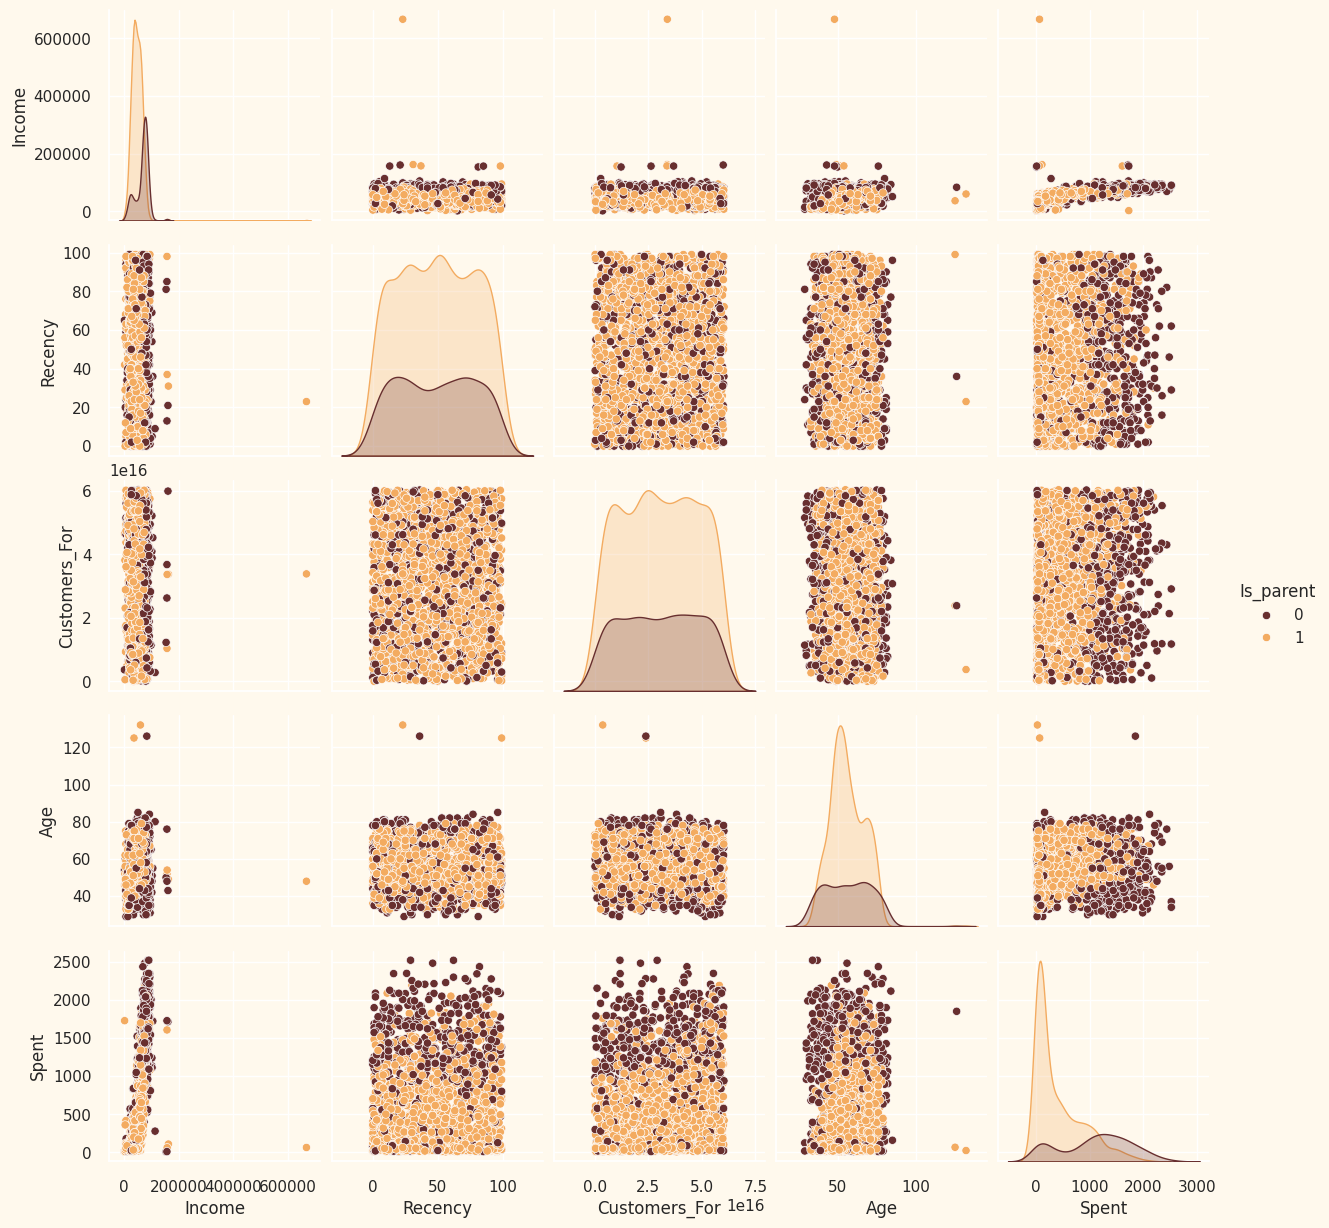

In [ ]:
#To plot some selected features

#Setting up colors preferences
sns.set(rc={'axes.facecolor':'#FFF9ED', 'figure.facecolor':'#FFF9ED'})
pallet = ['#682F2F', '#9EF726', '#D6B2B1', '#B9C0C9', '#9F8A78', '#F3AB60']
cmap = colors.ListedColormap(['#682F2F', '#9EF726', '#D6B2B1', '#B9C0C9', '#9F8A78', '#F3AB60'])

#Plotting following features
To_plot = ['Income', 'Recency', 'Customers_For', 'Age', 'Spent', 'Is_parent']
print("Relative plot of some selected features: A data Subset")
plt.figure()
sns.pairplot(data[To_plot], hue='Is_parent', palette=(["#682F2F", "#F3AB60"]))
plt.show()

In [ ]:
#Dropping the Outliers by settings a cap on Age and income.
data = data[(data["Age"]<90)]
data = data[(data["Income"]<600000)]
print("The total numbers of data-points after removing the outliers are:", len(data))


The total numbers of data-points after removing the outliers are: 2212


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   object 
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   int64  
 3   Teenhome             2212 non-null   int64  
 4   Recency              2212 non-null   int64  
 5   Wines                2212 non-null   int64  
 6   Fruits               2212 non-null   int64  
 7   Meat                 2212 non-null   int64  
 8   Fish                 2212 non-null   int64  
 9   Sweets               2212 non-null   int64  
 10  GoldProds            2212 non-null   int64  
 11  NumDealsPurchases    2212 non-null   int64  
 12  NumWebPurchases      2212 non-null   int64  
 13  NumCatalogPurchases  2212 non-null   int64  
 14  NumStorePurchases    2212 non-null   int64  
 15  NumWebVisitsMonth    2212 non-null   int64 

In [ ]:
# Get list of categorical variables
s = (data.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables in the dataset:", object_cols)

# Label encoding the object dtypes
LE = LabelEncoder()
for i in object_cols:
    data[i] = data[[i]].apply(LE.fit_transform)

print("All features are now numerical")

Categorical variables in the dataset: ['Education', 'Living_With']
All features are now numerical


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   int64  
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   int64  
 3   Teenhome             2212 non-null   int64  
 4   Recency              2212 non-null   int64  
 5   Wines                2212 non-null   int64  
 6   Fruits               2212 non-null   int64  
 7   Meat                 2212 non-null   int64  
 8   Fish                 2212 non-null   int64  
 9   Sweets               2212 non-null   int64  
 10  GoldProds            2212 non-null   int64  
 11  NumDealsPurchases    2212 non-null   int64  
 12  NumWebPurchases      2212 non-null   int64  
 13  NumCatalogPurchases  2212 non-null   int64  
 14  NumStorePurchases    2212 non-null   int64  
 15  NumWebVisitsMonth    2212 non-null   int64 

In [ ]:
# Creating a copy of the data
ds = data.copy()

# Creating a subset of columns to scale
# Since all features in 'data' are now numerical (after label encoding and feature engineering),
# we can scale the entire dataframe.

# Scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(ds)

# Creating a DataFrame of the scaled features
scaled_ds = pd.DataFrame(scaled_features, columns=ds.columns)

print("Scaled dataset shape:", scaled_ds.shape)
scaled_ds.head()

Scaled dataset shape: (2212, 29)


,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customers_For,Age,Spent,Living_With,children,Is_parent
0,-0.893586,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,...,-0.261914,-0.117256,-0.09552,2.375425,1.527721,1.018352,1.676245,-1.349603,-1.264598,-1.581139
1,-0.893586,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,...,-0.261914,-0.117256,-0.09552,-0.420977,-1.189011,1.274785,-0.963297,-1.349603,1.404572,0.632456
2,-0.893586,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,...,-0.261914,-0.117256,-0.09552,-0.420977,-0.206048,0.334530,0.280110,0.740959,-1.264598,-1.581139
3,-0.893586,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,...,-0.261914,-0.117256,-0.09552,-0.420977,-1.060584,-1.289547,-0.920135,0.740959,0.069987,0.632456
4,0.571657,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,...,-0.261914,-0.117256,-0.09552,-0.420977,-0.951915,-1.033114,-0.307562,0.740959,0.069987,0.632456


In [ ]:
# Initiating PCA to reduce dimensions to three
pca = PCA(n_components=3)
pca.fit(scaled_ds)
pca_ds = pd.DataFrame(pca.transform(scaled_ds), columns=(['col1', 'col2', 'col3']))

# Displaying the first few rows of the PCA dataset
print("PCA-transformed dataset shape:", pca_ds.shape)
pca_ds.head()

PCA-transformed dataset shape: (2212, 3)


,col1,col2,col3
0,4.635750,0.151978,0.182150
1,-2.904674,0.163948,-0.462404
2,2.256284,-0.796691,-1.189679
3,-2.712192,-1.559890,0.024875
4,-0.699909,-0.066960,-0.701392


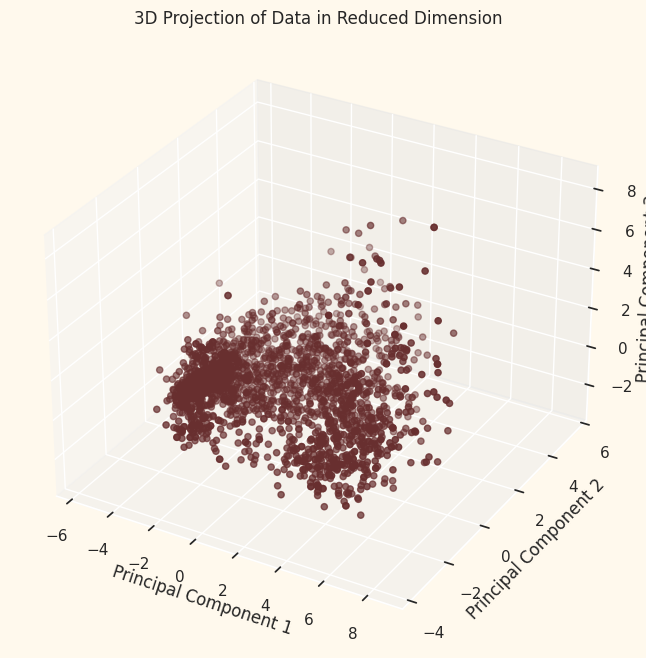

In [ ]:
import matplotlib.pyplot as plt

# Creating a 3D scatter plot of the principal components
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plotting the three components
ax.scatter(pca_ds['col1'], pca_ds['col2'], pca_ds['col3'], c='#682F2F', marker='o')

# Setting labels and title
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D Projection of Data in Reduced Dimension')

plt.show()

Elbow Method to determine the number of clusters to be formed:


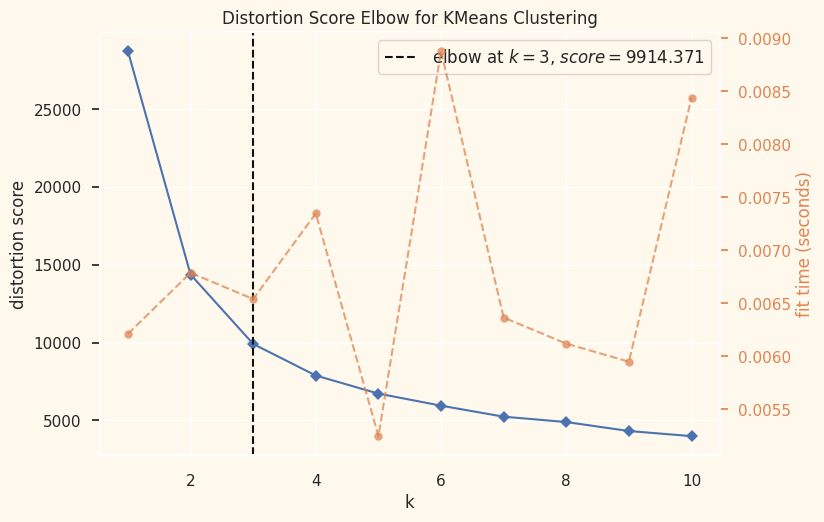

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
#Quick examination of elbow method to find numbers of clusters to make.
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(random_state=42), k=(1,11))
Elbow_M.fit(pca_ds)
Elbow_M.show()

In [ ]:
#Initialing the Agglomerative Clustering model
AC = AgglomerativeClustering(n_clusters=3)
#fit model and predict clusters
yhat_AC = AC.fit_predict(pca_ds)
PCA_ds = pca_ds.copy()
PCA_ds['cluster'] = yhat_AC
#Adding the Clusters features to the original dataframe.
data['cluster'] = yhat_AC

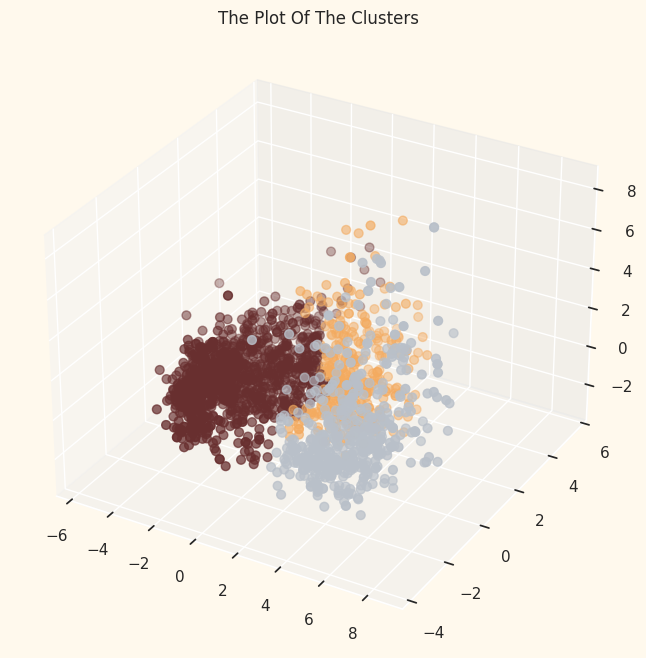

/tmp/ipython-input-3179133790.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl = sns.countplot(x=data['cluster'], palette=pallet)
/tmp/ipython-input-3179133790.py:10: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  pl = sns.countplot(x=data['cluster'], palette=pallet)


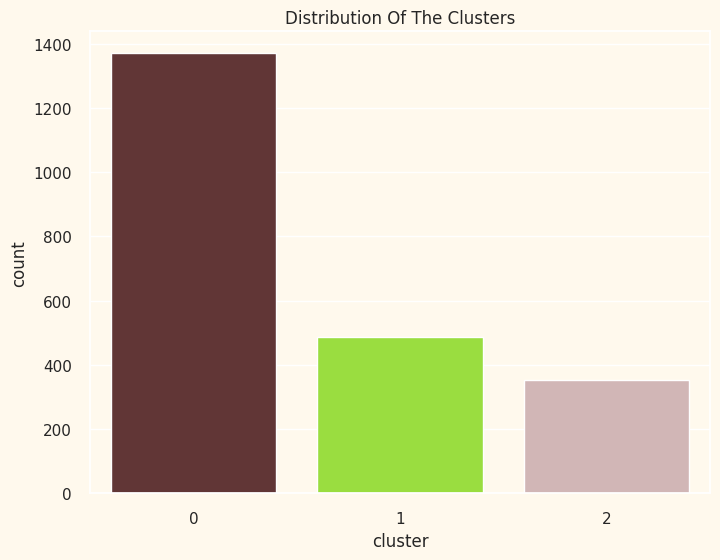

In [ ]:
# Plotting the Clusters
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(111, projection='3d', label='bla')
ax.scatter(PCA_ds['col1'], PCA_ds['col2'], PCA_ds['col3'], s=40, c=PCA_ds['cluster'], marker='o', cmap=cmap)
ax.set_title("The Plot Of The Clusters")
plt.show()

# Plotting countplot of clusters
plt.figure(figsize=(8, 6))
pl = sns.countplot(x=data['cluster'], palette=pallet)
pl.set_title("Distribution Of The Clusters")
plt.show()

/tmp/ipython-input-2098168535.py:2: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  pl = sns.scatterplot(data=data, x="Spent", y="Income", hue="cluster", palette=pallet)


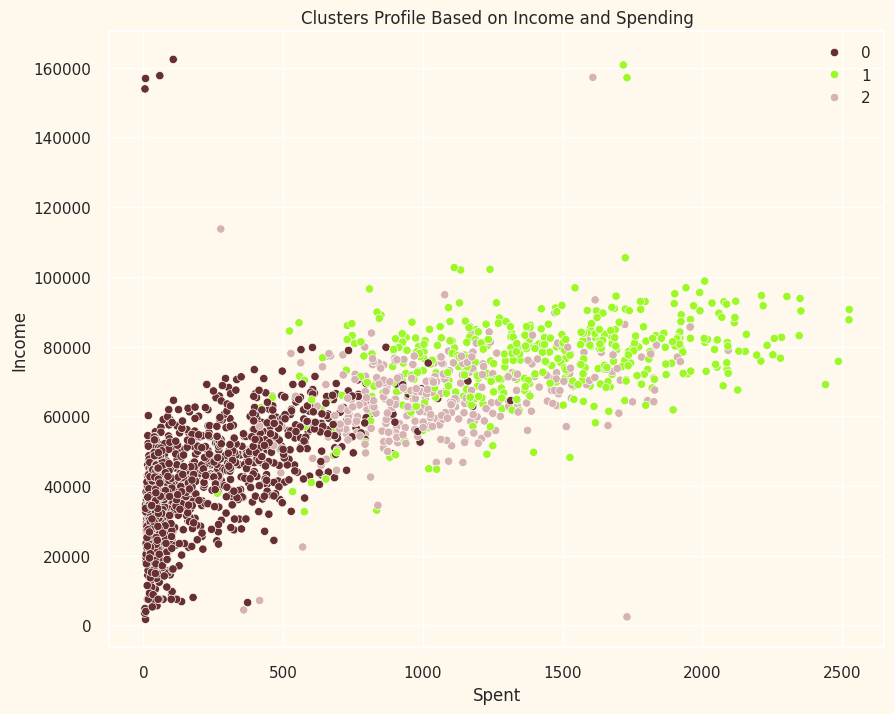

In [ ]:
plt.figure(figsize=(10, 8))
pl = sns.scatterplot(data=data, x="Spent", y="Income", hue="cluster", palette=pallet)
plt.title('Clusters Profile Based on Income and Spending')
plt.legend()
plt.show()

# Task
Fix the scatterplot visualization errors (KeyError and typos) for the customer segments based on "Income" and "Spent" using the processed data from "/content/marketing_campaign.csv". Then, perform cluster profiling by analyzing the distribution of "Age" and "Is_parent" across the segments to define customer personas.

## Correct Scatterplot Visualization

### Subtask:
Fix the KeyError and typos in the scatterplot to visualize customer segments based on income and spending.


**Reasoning**:
Correct the KeyError and parameter typos in the scatterplot to visualize the relationship between income and spending across clusters.



/tmp/ipython-input-99896246.py:2: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(data=data, x='Spent', y='Income', hue='cluster', palette=pallet)


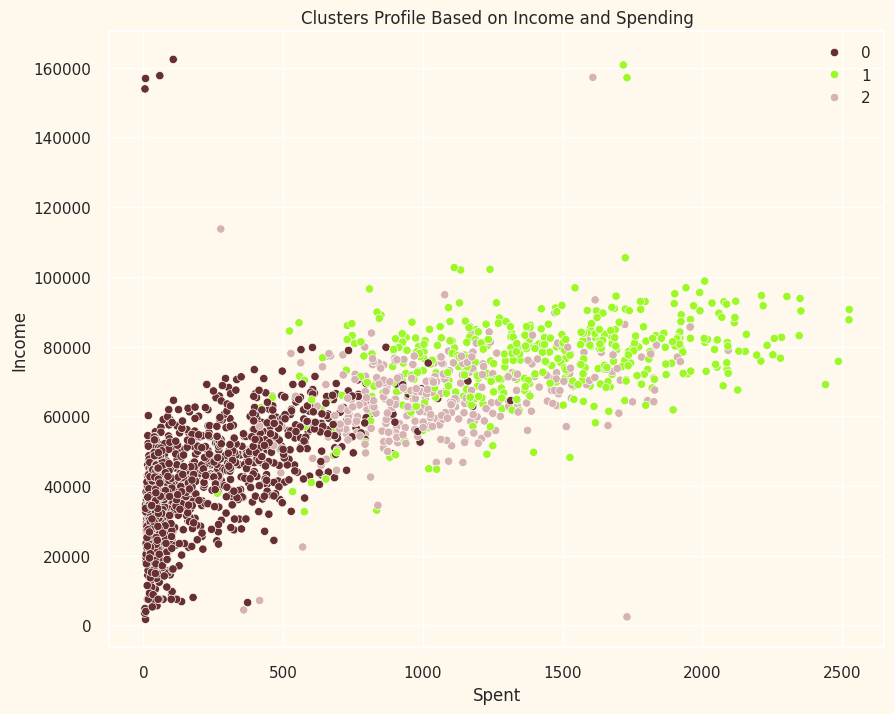

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=data, x='Spent', y='Income', hue='cluster', palette=pallet)
plt.title('Clusters Profile Based on Income and Spending')
plt.legend()
plt.show()

**Reasoning**:
The scatterplot visualization has been corrected to show the relationship between 'Spent' and 'Income' across clusters. Now, I will proceed to the next part of the task: cluster profiling. I'll analyze the distribution of 'Age' and 'Is_parent' across the identified segments using visualizations and summary statistics to define distinct customer personas.



/tmp/ipython-input-2634398995.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='cluster', y='Age', data=data, palette=pallet[:3])
/tmp/ipython-input-2634398995.py:14: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.countplot(x='cluster', hue='Is_parent', data=data, palette=pallet[:3])


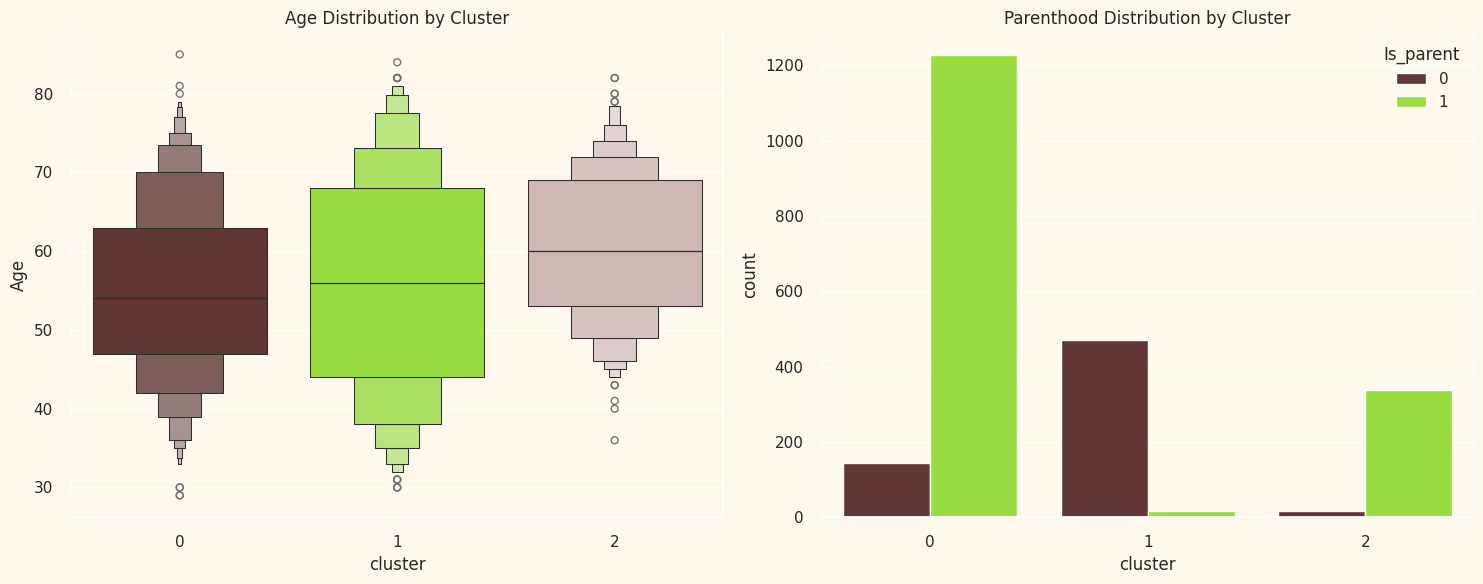

Average metrics per cluster for persona profiling:


,Age,Is_parent,Income,Spent
cluster,,,,
0,54.937956,0.894891,39817.311679,202.970073
1,56.219262,0.034836,76337.342213,1403.184426
2,60.347458,0.951977,65340.533898,1074.728814


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cluster Profiling: Analyzing Age and Is_parent distributions across clusters
plt.figure(figsize=(15, 6))

# Visualizing Age distribution for each cluster
plt.subplot(1, 2, 1)
sns.boxenplot(x='cluster', y='Age', data=data, palette=pallet[:3])
plt.title('Age Distribution by Cluster')

# Visualizing Parenthood distribution for each cluster
plt.subplot(1, 2, 2)
sns.countplot(x='cluster', hue='Is_parent', data=data, palette=pallet[:3])
plt.title('Parenthood Distribution by Cluster')

plt.tight_layout()
plt.show()

# Displaying group averages to refine persona definitions
print("Average metrics per cluster for persona profiling:")
display(data.groupby('cluster')[['Age', 'Is_parent', 'Income', 'Spent']].mean())

**Reasoning**:
The cluster profiling has been performed, and the metrics are available. I will now create a clean set of visualizations to define the customer personas, ensuring the code is free of warnings and effectively distinguishes between the segments.



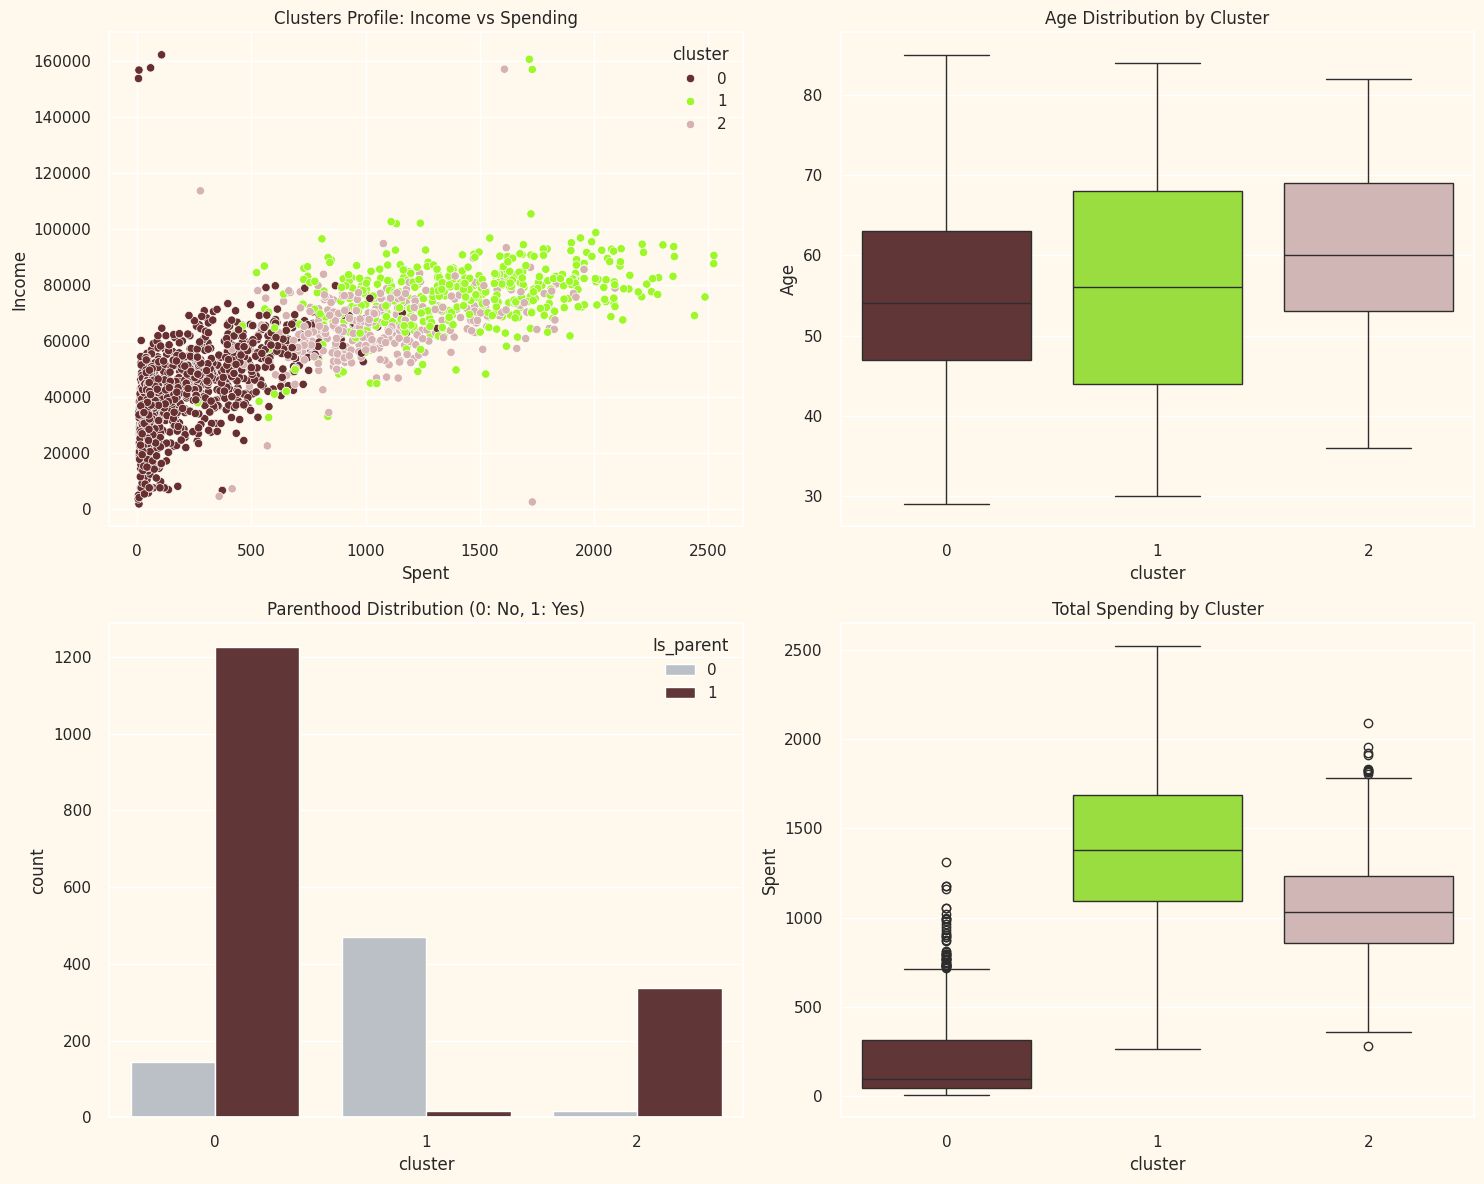


Summary Metrics for Customer Personas:


,Age,Is_parent,Income,Spent
cluster,,,,
0,54.937956,0.894891,39817.311679,202.970073
1,56.219262,0.034836,76337.342213,1403.184426
2,60.347458,0.951977,65340.533898,1074.728814



Customer Personas Based on Analysis:
Cluster 0: 'Budget-Conscious Parents' - Lower income and spending; mostly parents.
Cluster 1: 'Wealthy Non-Parents' - High income and high spending; almost no children.
Cluster 2: 'Affluent Parents' - High income and high spending; mostly parents.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Defining a specific palette for the clusters for consistency
cluster_palette = pallet[:3]

# Setting up the figure for profiling
plt.figure(figsize=(15, 12))

# 1. Scatterplot: Income vs Spending (Fixed version)
plt.subplot(2, 2, 1)
sns.scatterplot(data=data, x='Spent', y='Income', hue='cluster', palette=cluster_palette)
plt.title('Clusters Profile: Income vs Spending')

# 2. Boxplot: Age Distribution
plt.subplot(2, 2, 2)
sns.boxplot(x='cluster', y='Age', data=data, hue='cluster', palette=cluster_palette, legend=False)
plt.title('Age Distribution by Cluster')

# 3. Countplot: Parenthood Distribution
plt.subplot(2, 2, 3)
sns.countplot(x='cluster', hue='Is_parent', data=data, palette=['#B9C0C9', '#682F2F'])
plt.title('Parenthood Distribution (0: No, 1: Yes)')

# 4. Boxplot: Total Spending
plt.subplot(2, 2, 4)
sns.boxplot(x='cluster', y='Spent', data=data, hue='cluster', palette=cluster_palette, legend=False)
plt.title('Total Spending by Cluster')

plt.tight_layout()
plt.show()

# Final summary for Persona Definition
persona_summary = data.groupby('cluster')[['Age', 'Is_parent', 'Income', 'Spent']].mean()
print("\nSummary Metrics for Customer Personas:")
display(persona_summary)

print("\nCustomer Personas Based on Analysis:")
print("Cluster 0: 'Budget-Conscious Parents' - Lower income and spending; mostly parents.")
print("Cluster 1: 'Wealthy Non-Parents' - High income and high spending; almost no children.")
print("Cluster 2: 'Affluent Parents' - High income and high spending; mostly parents.")

/tmp/ipython-input-1057527890.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl = sns.countplot(x=data['Total_Promos'], palette=pallet)
/tmp/ipython-input-1057527890.py:4: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  pl = sns.countplot(x=data['Total_Promos'], palette=pallet)


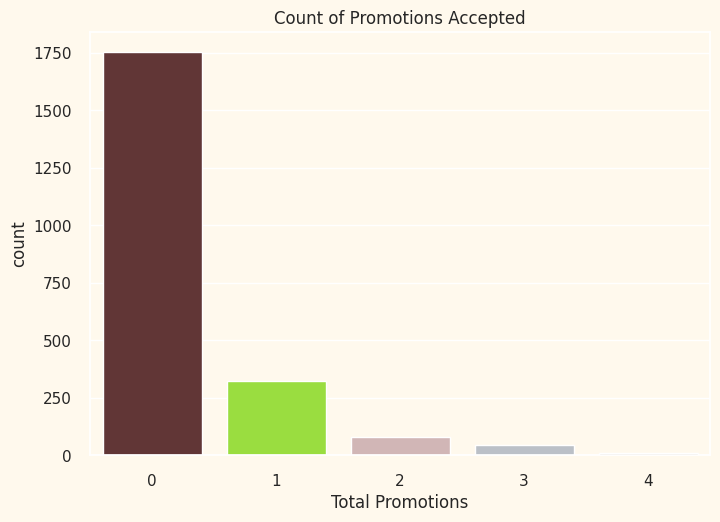

In [ ]:
#Creating a features to get a sum of accepted promtions
data["Total_Promos"] = data['AcceptedCmp1']+data['AcceptedCmp2']+data['AcceptedCmp3']+data['AcceptedCmp4']+data['AcceptedCmp5']
plt.figure()
pl = sns.countplot(x=data['Total_Promos'], palette=pallet)
pl.set_title("Count of Promotions Accepted")
pl.set_xlabel("Total Promotions")
plt.show()

/tmp/ipython-input-3880852345.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl = sns.countplot(x=data['NumDealsPurchases'], palette=pallet)
/tmp/ipython-input-3880852345.py:3: UserWarning: 
The palette list has fewer values (6) than needed (15) and will cycle, which may produce an uninterpretable plot.
  pl = sns.countplot(x=data['NumDealsPurchases'], palette=pallet)


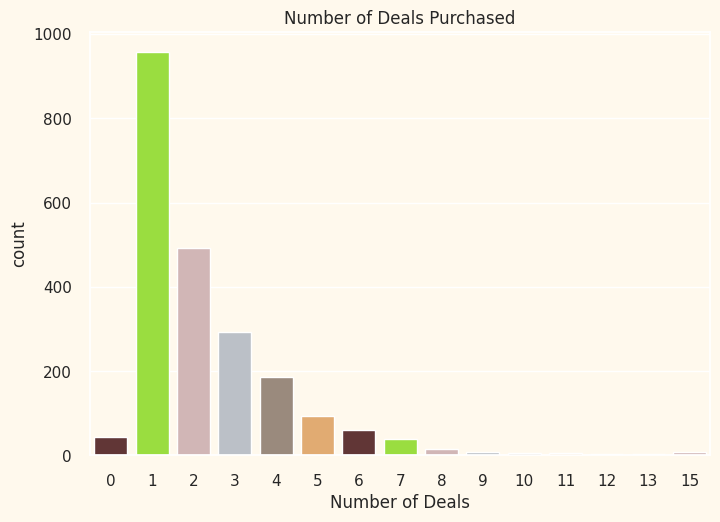

In [ ]:
#Plotting the numbers of deals purchased
plt.figure()
pl = sns.countplot(x=data['NumDealsPurchases'], palette=pallet)
pl.set_title("Number of Deals Purchased")
pl.set_xlabel("Number of Deals")
plt.show()

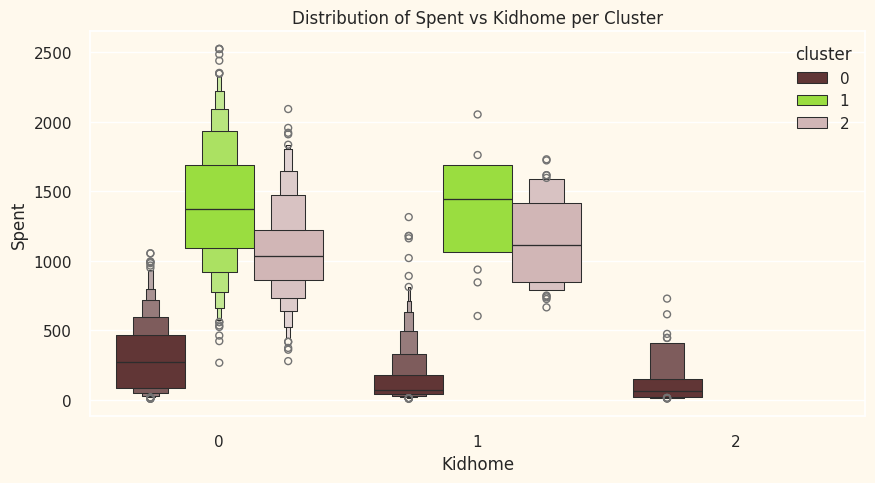

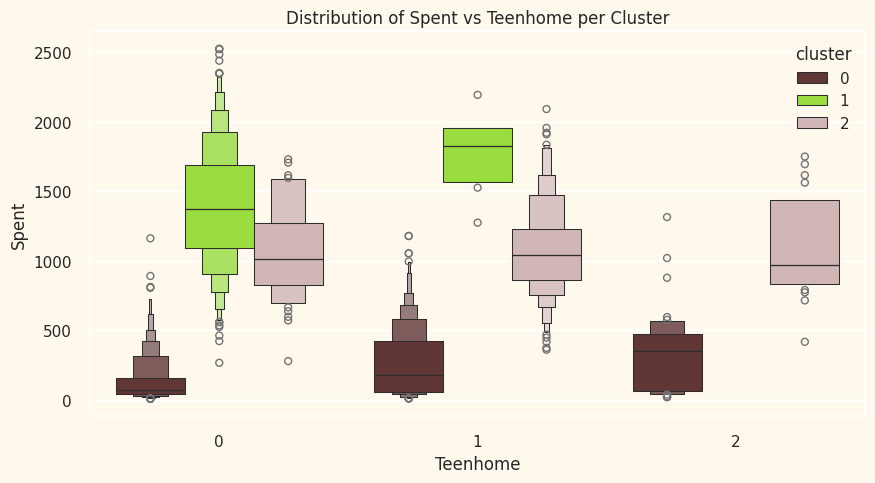

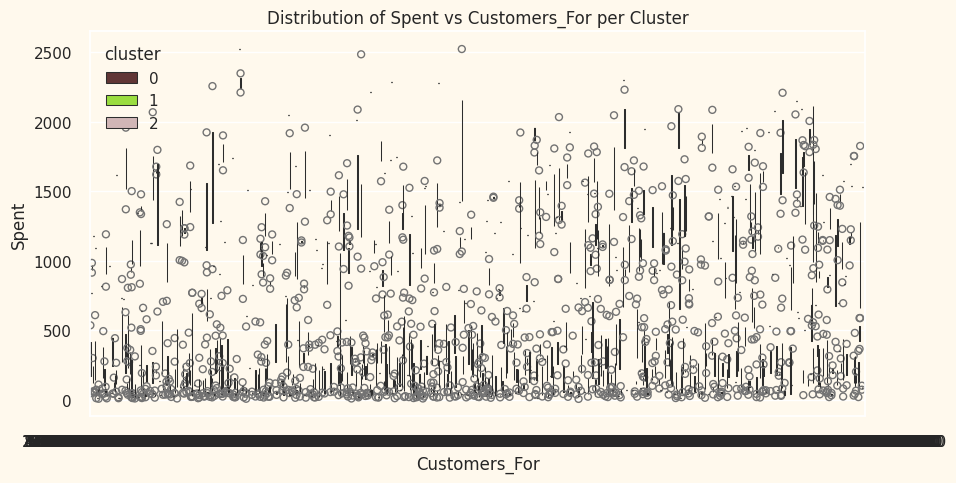

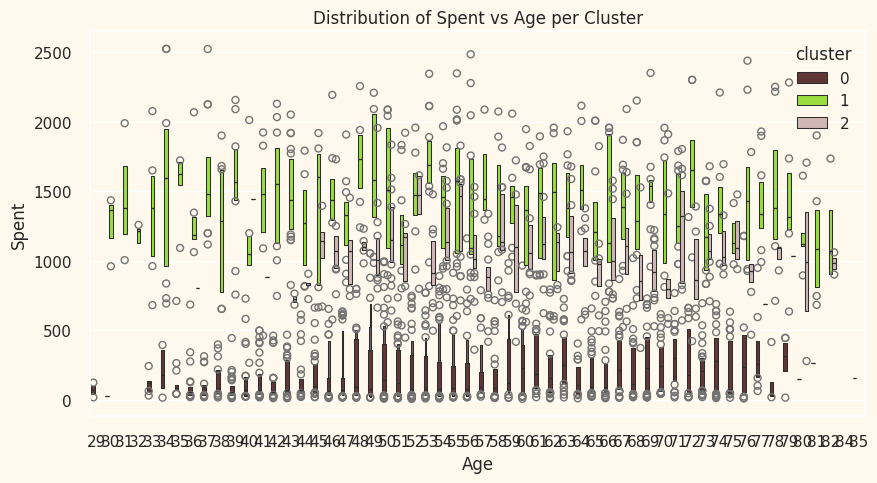

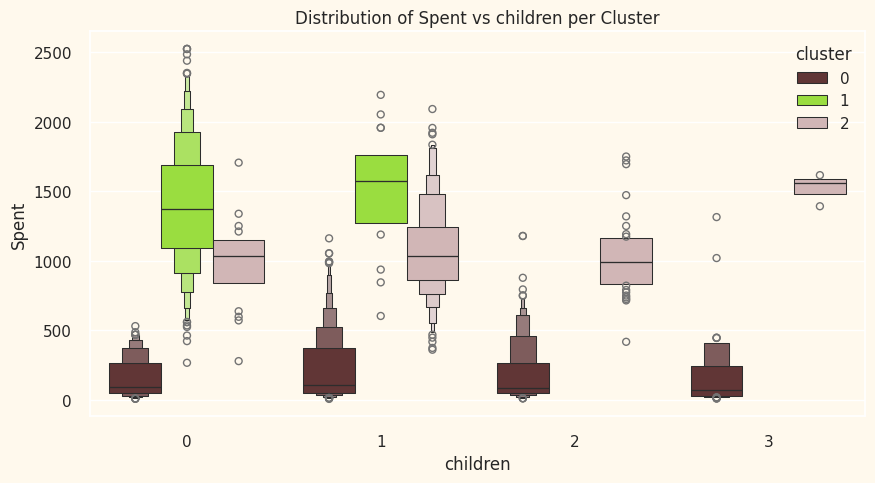

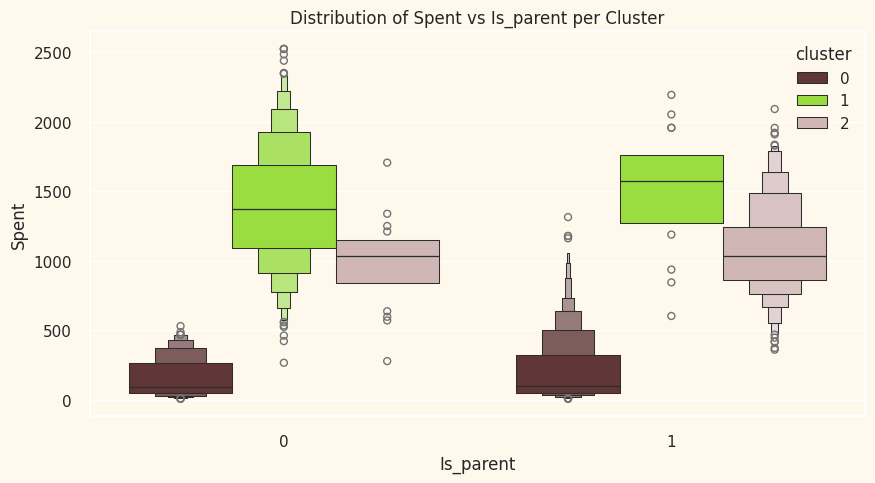

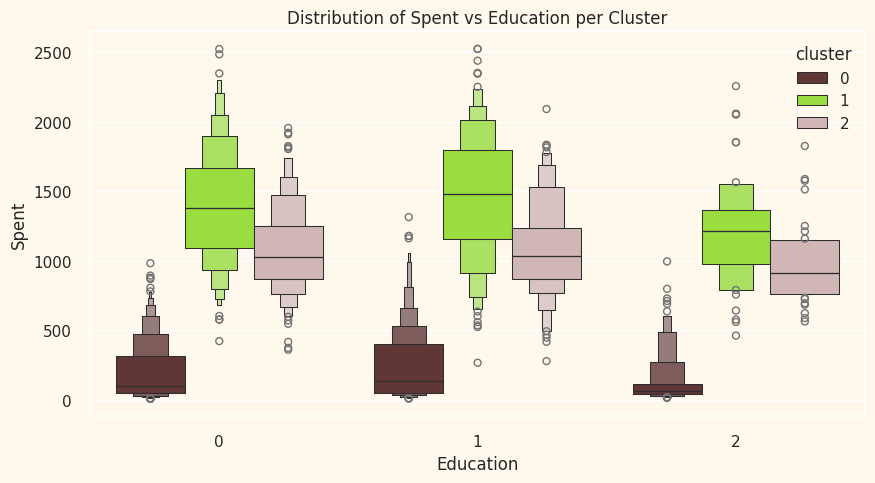

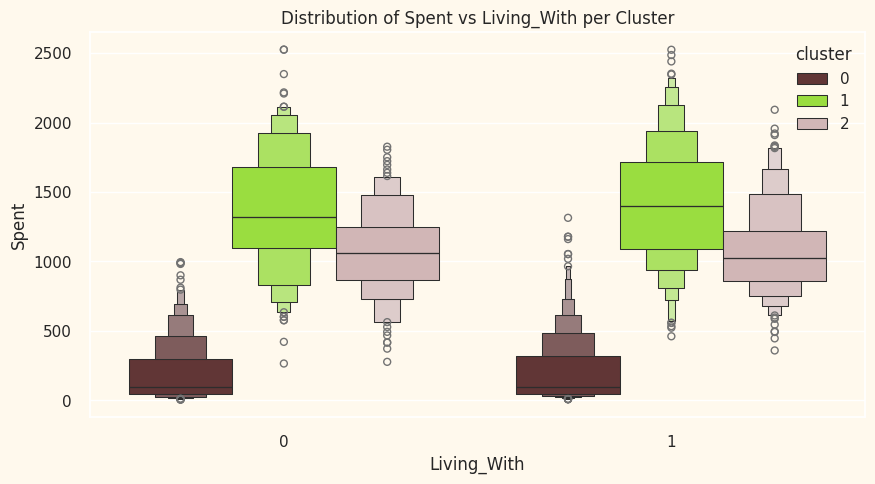

In [ ]:
# Fixed list of features with correct spelling and case
# Note: 'Familiy_size' was removed as it is not in the dataset
Personal = ["Kidhome", "Teenhome", "Customers_For", "Age", "children", "Is_parent", "Education", "Living_With"]

for i in Personal:
    plt.figure(figsize=(10, 5))
    # Using boxenplot to compare 'Spent' across feature 'i' grouped by clusters
    sns.boxenplot(x=data[i], y=data['Spent'], hue=data['cluster'], palette=pallet[:3])
    plt.title(f'Distribution of Spent vs {i} per Cluster')
    plt.show()